In [1]:
import re
import time
import numpy as np
import pandas as pd
import scipy.optimize
import matplotlib.pyplot as plt
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.nquality import QualityBuilder
from pipedream_solver.simulation import Simulation
from pipedream_solver.nutils import bounded_newton_raphson
import pipedream_solver.ngeometry
import swmmio
import swmmtoolbox

In [2]:
def compute_normal_depth(h, f_A, f_Pe, Q, n, S_o, *args):
    A = f_A(h, *args)
    Pe = f_Pe(h, *args)
    result = Q - np.sqrt(S_o) * A**(5/3) / Pe**(2/3) / n
    return result

def compute_critical_depth(h, f_A, f_B, Q, *args):
    A = f_A(h, *args)
    B = f_B(h, *args)
    g = 9.81
    result = 1 - Q**2 * B / g / A**3
    return result

def normal_depth(f_A, f_Pe, Q, n, S_o, *args, min_depth=1e-10, max_depth=100.):
    result = scipy.optimize.root_scalar(compute_normal_depth, method='bisect',
                                        bracket=[min_depth, max_depth],
                                        args=(f_A, f_Pe, Q, n,
                                              S_o, *args))
    h = result.root
    return h
    
def critical_depth(f_A, f_B, Q, *args, min_depth=1e-10, max_depth=100.):
    result = scipy.optimize.root_scalar(compute_critical_depth, method='bisect',
                                        bracket=[min_depth, max_depth],
                                        args=(f_A, f_B, Q, *args))
    h = result.root
    return h

In [3]:
swmm = swmmio.Model('../data/user1/user1.inp')

In [4]:
links = swmm.links()
nodes = swmm.nodes()
orifices = swmm.orifices()
weirs = swmm.weirs()
pumps = swmm.pumps()

In [5]:
superjunctions = nodes.reset_index()
assert swmm.inp.options.loc['FLOW_UNITS', 'Value'] == 'CMS'
superjunctions = superjunctions.rename(columns={'Name' : 'name', 'InvertElev' : 'z_inv',
                                                'MaxDepth' : 'max_depth', 'InitDepth' : 'h_0'})
superjunctions['map_x'] = superjunctions['coords'].str[0].str[0]
superjunctions['map_y'] = superjunctions['coords'].str[0].str[1]
superjunctions['bc'] = ~superjunctions['OutfallType'].isnull()
superjunctions = superjunctions.drop(['SurchargeDepth', 'PondedArea', 'OutfallType', 'StageOrTimeseries', 'coords'], axis=1)
superjunctions['storage'] = 'functional'
superjunctions['a'] = 0.
superjunctions['b'] = 0.
superjunctions['c'] = 1.16
superjunctions['id'] = superjunctions.index

#superjunctions['z_inv'] *= 0.3048
#superjunctions['h_0'] *= 0.3048
#superjunctions['max_depth'] *= 0.3048

superjunctions['max_depth'].replace(np.nan, np.inf, inplace=True)
superjunctions['h_0'].replace(np.nan, 0., inplace=True)

In [6]:
superlinks = links.reset_index()
assert (superlinks['Barrels'] == 1).all()
node_map = superjunctions.set_index('name')['id']
superlinks['InletNode'] = superlinks['InletNode'].map(node_map)
superlinks['OutletNode'] = superlinks['OutletNode'].map(node_map)
superlinks['Shape'] = superlinks['Shape'].str.lower()
#superlinks['Length'] *= 0.3048
#superlinks['Geom1'] *= 0.3048
#superlinks['Geom2'] *= 0.3048
#superlinks['Geom3'] *= 0.3048
#superlinks['Geom4'] *= 0.3048
#superlinks['InOffset'] *= 0.3048
#superlinks['OutOffset'] *= 0.3048
#superlinks['InitFlow'] *= 0.028316832
superlinks = superlinks.rename(columns={'InletNode' : 'sj_0', 'OutletNode' : 'sj_1',
                                        'Name' : 'name', 'Length' : 'dx',
                                        'Roughness' : 'roughness', 'Shape' : 'shape',
                                        'Geom1' : 'g1', 'Geom2' : 'g2', 'Geom3' : 'g3',
                                        'Geom4' : 'g4', 'InOffset' : 'in_offset', 
                                        'OutOffset' : 'out_offset', 'InitFlow' : 'Q_0'})
superlinks = superlinks.drop(['MaxFlow', 'Barrels', 'coords'], axis=1)
superlinks['A_s'] = 1e-5
superlinks['A_c'] = 0.
superlinks['C'] = 0.
superlinks['ctrl'] = False
superlinks['C_uk'] = 0.
superlinks['C_dk'] = 0.
superlinks['h_0'] = 1e-5

In [7]:
model = SuperLink(superlinks, superjunctions, internal_links=4)

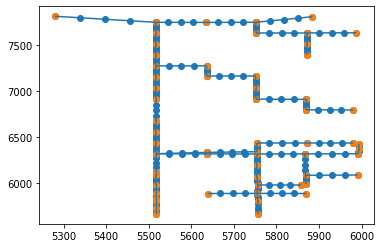

In [8]:
model.plot_network_2d()

In [9]:
total_inflow = swmmtoolbox.extract('../data/user1/user1.out', 'node,,Lateral_inflow')
node_heads = swmmtoolbox.extract('../data/user1/user1.out', 'node,,Hydraulic_head')
link_flows = swmmtoolbox.extract('../data/user1/user1.out', 'link,,Flow_rate')

In [10]:
start_time = pd.to_datetime(swmm.inp.options.loc['START_DATE'] + ' ' + swmm.inp.options.loc['START_TIME'])['Value']

In [11]:
total_inflow.columns = total_inflow.columns.str.extract('node_(.*)_Lateral_inflow')
total_inflow.columns = total_inflow.columns.str[0]
total_inflow = total_inflow[model.superjunctions['name'].values]

In [12]:
Q_in = total_inflow.copy()
Q_in.fillna(0., inplace=True)
Q_in.index = 1e-9 * (Q_in.index - Q_in.index[0]).astype(int)

In [13]:
node_heads.columns = node_heads.columns.str.extract('node_(.*)_Hydraulic_head')
node_heads.columns = node_heads.columns.str[0]
node_heads = node_heads[model.superjunctions['name'].values]

link_flows.columns = link_flows.columns.str.extract('link_(.*)_Flow_rate')
link_flows.columns = link_flows.columns.str[0]
link_flows = link_flows[model.superlinks['name'].values]

In [14]:
k = np.flatnonzero(np.in1d(model._J_dk, np.flatnonzero(model.bc))).item()
sel = model._ki == k
S_o = model._S_o_ik[sel].mean()
n = model._n_ik[sel].mean()
g1 = model._g1_ik[sel].mean()
g2 = model._g2_ik[sel].mean()
g3 = model._g3_ik[sel].mean()

In [15]:
dt = 5

with Simulation(model, Q_in=Q_in, t_end=8*3600) as simulation:
    # While simulation time has not expired...
    while simulation.t <= simulation.t_end:
        Q_bc = model._Q_ik[sel].mean()
        #h_n = normal_depth(pipedream_solver.ngeometry.Circular_A_ik,
        #                   pipedream_solver.ngeometry.Circular_Pe_ik, Q_bc, n, S_o, g1, g2)
        #h_c = critical_depth(pipedream_solver.ngeometry.Circular_A_ik,
        #                     pipedream_solver.ngeometry.Circular_B_ik, Q_bc, g1, g2)
        #h_bc = min(h_n, h_c)
        #H_bc = np.where(model.bc, model._z_inv_j + h_bc, 0.)
        # Step model forward in time
        #simulation.step(dt=dt, H_bc=H_bc, num_iter=1)
        simulation.step(dt=dt, num_iter=8)
        # Record internal depth and flow states
        simulation.record_state()
        # Print progress bar
        simulation.print_progress()

[==================================================] 100.0% [1.63 s]

<AxesSubplot:>

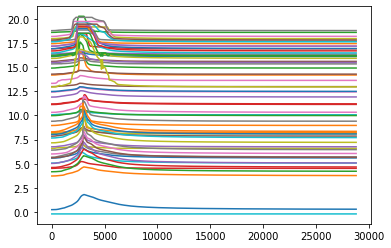

In [16]:
simulation.states.H_j.plot(legend=False)

In [17]:
H_j = simulation.states.H_j.copy()
H_j.index = pd.to_timedelta(H_j.index, unit='s') + start_time

In [18]:
Q_ik = simulation.states.Q_ik.copy()
Q_ik.index = pd.to_timedelta(Q_ik.index, unit='s') + start_time

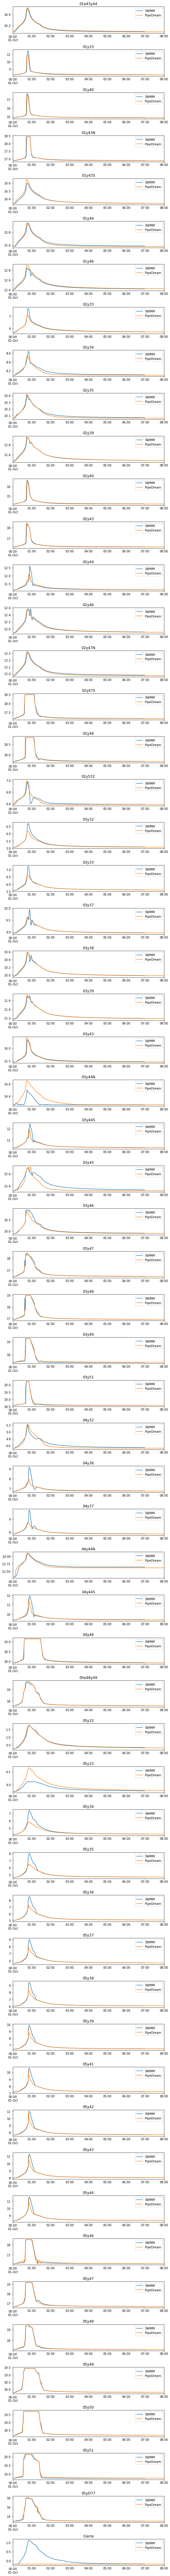

In [19]:
fig, ax = plt.subplots(len(node_heads.columns), figsize=(8, 120))
for i, index in enumerate(node_heads.columns):
    (node_heads[index]).plot(ax=ax[i], label='SWMM')
    (H_j[index]).plot(ax=ax[i], label='PipeDream')
    ax[i].set_title(index)
    ax[i].legend()
plt.tight_layout()

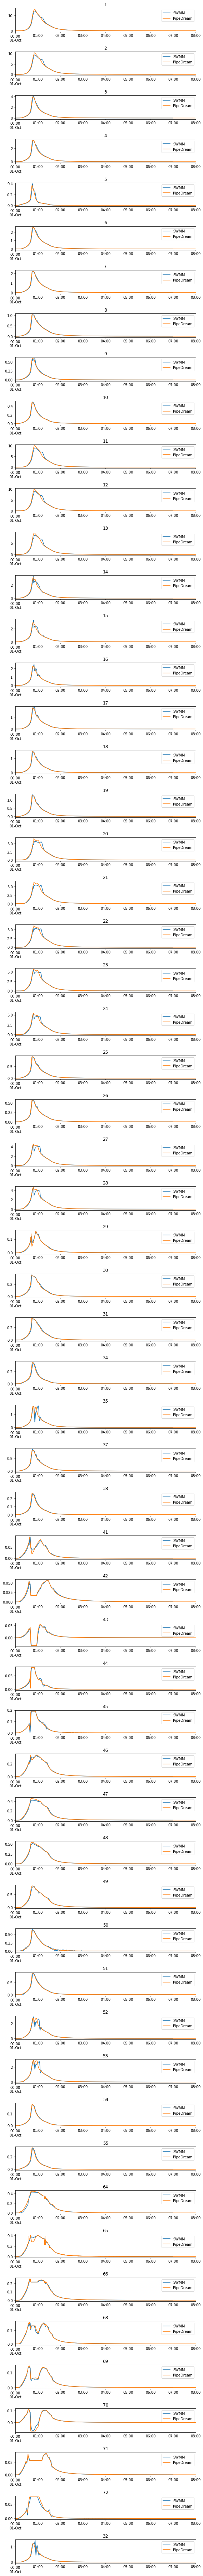

In [20]:
fig, ax = plt.subplots(len(link_flows.columns), figsize=(8, 100))
for i, index in enumerate(link_flows.columns):
    junctions = np.flatnonzero(model._ki == model.superlinks.reset_index().set_index('name').loc[index, 'index'])
    (link_flows[index]).plot(ax=ax[i], label='SWMM')
    Q_ik[junctions].mean(axis=1).plot(ax=ax[i], label='PipeDream')
    ax[i].set_title(index)
    ax[i].legend()
plt.tight_layout()

<AxesSubplot:>

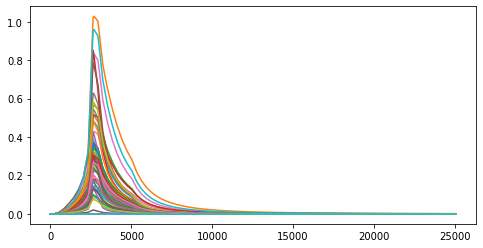

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
Q_in.plot(ax=ax, legend=False)